# Individual Homework 04: Python Coding Audit
## From Accuracy to Accountability: Stress Testing a Predictive Model


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load and Prepare COMPAS Data

The target is score_binary, where 1 = High COMPAS score and 0 = Low/Medium COMPAS score`. Race is included as an input here because the asignment asks us to test whether the model relies on protected attributes and whether performance differs across race slices. In a real deploymentz, this design choice would requie strong governance review.

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_raw = pd.read_csv(url)

# Lecture-style COMPAS filtering.
df = df_raw[
    (df_raw["days_b_screening_arrest"].between(-30, 30)) &
    (df_raw["is_recid"] != -1) &
    (df_raw["c_charge_degree"] != "O") &
    (df_raw["score_text"] != "N/A")
].copy()

# Binary target for this predictive audit.
df["score_binary"] = (df["score_text"] == "High").astype(int)

features = ["age", "priors_count", "race", "sex", "c_charge_degree"]
target = "score_binary"

X = df[features].copy()
y = df[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Raw dataset rows: {df_raw.shape[0]:,}")
print(f"Filtered analytic dataset rows: {df.shape[0]:,}")
print(f"Train rows: {X_train.shape[0]:,}; Test rows: {X_test.shape[0]:,}")
print(f"Target rate in full analytic data: {y.mean():.3f}")
display(X.head())

Raw dataset rows: 7,214
Filtered analytic dataset rows: 6,172
Train rows: 4,937; Test rows: 1,235
Target rate in full analytic data: 0.185


,age,priors_count,race,sex,c_charge_degree
0,69,0,Other,Male,F
1,34,0,African-American,Male,F
2,24,4,African-American,Male,F
5,44,0,Other,Male,M
6,41,14,Caucasian,Male,F


## 2. Model Training

The notebook trains both models used in the lecture pipeline: Logistic Regression as an interpretable baseline and Gradient-Boosted Trees as a higher-capacity model.

In [3]:
numeric_features = ["age", "priors_count"]
categorical_features = ["race", "sex", "c_charge_degree"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

gb = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

models = {
    "Logistic Regression": lr,
    "Gradient Boosting": gb,
}

for model in models.values():
    model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


## Part A: Distribution Drift

This section checks whether the train and test feature distributions changed. It reports PSI and KS tests for numeric features and MMD in the encoded feature space.

In [5]:
def psi_numeric(expected, actual, bins=10, eps=1e-6):
    """Population Stability Index using quantile bins from the expected/reference sample."""
    expected = pd.Series(expected).dropna().astype(float).values
    actual = pd.Series(actual).dropna().astype(float).values
    cuts = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(cuts) <= 2:
        cuts = np.linspace(min(expected.min(), actual.min()), max(expected.max(), actual.max()), bins + 1)
    cuts[0], cuts[-1] = -np.inf, np.inf
    e_counts = np.histogram(expected, bins=cuts)[0]
    a_counts = np.histogram(actual, bins=cuts)[0]
    e_pct = np.clip(e_counts / max(e_counts.sum(), 1), eps, None)
    a_pct = np.clip(a_counts / max(a_counts.sum(), 1), eps, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))


def mmd_rbf(X1, X2, gamma=None, max_n=500, random_state=RANDOM_STATE):
    """RBF-kernel MMD^2 using a subsample to keep memory stable in Colab."""
    rng = np.random.default_rng(random_state)
    X1 = np.asarray(X1)
    X2 = np.asarray(X2)
    if X1.shape[0] > max_n:
        X1 = X1[rng.choice(X1.shape[0], size=max_n, replace=False)]
    if X2.shape[0] > max_n:
        X2 = X2[rng.choice(X2.shape[0], size=max_n, replace=False)]
    if gamma is None:
        gamma = 1 / X1.shape[1]
    Kxx = rbf_kernel(X1, X1, gamma=gamma)
    Kyy = rbf_kernel(X2, X2, gamma=gamma)
    Kxy = rbf_kernel(X1, X2, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2 * Kxy.mean())

# Numeric feature drift.
drift_rows = []
for col in numeric_features:
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])
    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_numeric(X_train[col], X_test[col]),
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
display(drift_table.round(4))

# High-dimensional MMD after encoding.
fitted_preprocess = lr.named_steps["preprocess"]
X_train_enc = fitted_preprocess.transform(X_train)
X_test_enc = fitted_preprocess.transform(X_test)
mmd_value = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500)
print(f"MMD^2 in encoded feature space: {mmd_value:.6f}")

max_psi = drift_table["PSI"].max()
min_ks_p = drift_table["KS_pvalue"].min()
print("\nAnswer:")
print(
    f"The largest numeric PSI is {max_psi:.4f}, which is below the 0.10 stability threshold. "
    f"The smallest KS p-value is {min_ks_p:.4g}; p-values above 0.05 do not indicate significant univariate drift. "
    f"The encoded-space MMD^2 is {mmd_value:.6f}. Together, these results do not show meaningful train/test distribution drift."
)

,feature,train_mean,test_mean,PSI,KS_stat,KS_pvalue
0,age,34.5264,34.5668,0.0076,0.0167,0.9409
1,priors_count,3.2273,3.3231,0.0022,0.0154,0.9700


MMD^2 in encoded feature space: 0.001922

Answer:
The largest numeric PSI is 0.0076, which is below the 0.10 stability threshold. The smallest KS p-value is 0.9409; p-values above 0.05 do not indicate significant univariate drift. The encoded-space MMD^2 is 0.001922. Together, these results do not show meaningful train/test distribution drift.




The maximum PSI is 0.0076, which is well below the 0.10 threshold, indicating no meaningful covariate shift. The KS test yields a minimum p-value of 0.9409, which is far above 0.05, so we do not reject the null of equal distributions.

The MMD value (0.001922) is also very small, confirming that the joint feature distribution is stable.
There is no evidence of distribution drift between training and test data.

## Part B: Generalization

This section compares train and test AUC, accuracy, Brier score, and log loss. It  reports the generalization gap as train AUC − test AUC.

In [9]:
def evaluate_model(model, name):
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    train_pred = (train_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)
    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)
    return {
        "model": name,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap_auc": train_auc - test_auc,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_brier": brier_score_loss(y_train, train_prob),
        "test_brier": brier_score_loss(y_test, test_prob),
        "train_logloss": log_loss(y_train, train_prob),
        "test_logloss": log_loss(y_test, test_prob),
    }

generalization_table = pd.DataFrame([
    evaluate_model(model, name) for name, model in models.items()
])
display(generalization_table.round(4))

print("\nAnswer:")
for _, row in generalization_table.iterrows():
    gap = row["generalization_gap_auc"]
    if abs(gap) <= 0.05:
        conclusion = "small, so there is no strong evidence of overfitting from AUC alone"
    else:
        conclusion = "large enough to raise overfitting or instability concerns"
    print(
        f"{row['model']}: train AUC = {row['train_auc']:.3f}, test AUC = {row['test_auc']:.3f}, "
        f"generalization gap = {gap:.3f}. This gap is {conclusion}."
    )

,model,train_auc,test_auc,generalization_gap_auc,train_accuracy,test_accuracy,train_brier,test_brier,train_logloss,test_logloss
0,Logistic Regression,0.8312,0.8367,-0.0054,0.8459,0.8372,0.1123,0.1122,0.3624,0.3585
1,Gradient Boosting,0.8575,0.8328,0.0247,0.8617,0.8316,0.1027,0.1148,0.3330,0.3648



Answer:
Logistic Regression: train AUC = 0.831, test AUC = 0.837, generalization gap = -0.005. This gap is small, so there is no strong evidence of overfitting from AUC alone.
Gradient Boosting: train AUC = 0.857, test AUC = 0.833, generalization gap = 0.025. This gap is small, so there is no strong evidence of overfitting from AUC alone.




Logistic Regression has a train AUC of 0.831 and test AUC of 0.837, yielding a generalization gap of -0.005, which indicates stable performance with no overfitting.

Gradient Boosting has a train AUC of 0.857 and test AUC of 0.833, producing a gap of 0.025. This gap is still small, suggesting only mild overfitting.

Both models generalize well, though Gradient Boosting shows slightly higher variance consistent with its higher model capacity.

## Part C: Spurious-Correlation Probe

This section performs counterfactual swaps for protected attributes while holding all other fields fixed. Large prediction shifts suggest shortcut learning or reliance on protected attributes/proxies.

In [11]:
def counterfactual_swap_shift(model, X_ref, col, a, b):
    """Swap a -> b and b -> a in one feature and measure absolute probability shifts."""
    X_cf = X_ref.copy()
    mask_a = X_cf[col] == a
    mask_b = X_cf[col] == b
    X_cf.loc[mask_a, col] = b
    X_cf.loc[mask_b, col] = a
    before = model.predict_proba(X_ref)[:, 1]
    after = model.predict_proba(X_cf)[:, 1]
    shifted = mask_a | mask_b
    return {
        "feature": col,
        "swap": f"{a} <-> {b}",
        "n_swapped": int(shifted.sum()),
        "mean_abs_shift": float(np.mean(np.abs(before[shifted] - after[shifted]))),
        "max_abs_shift": float(np.max(np.abs(before[shifted] - after[shifted]))),
    }

swap_rows = []
for name, model in models.items():
    for args in [
        ("race", "African-American", "Caucasian"),
        ("sex", "Male", "Female"),
    ]:
        result = counterfactual_swap_shift(model, X_test, *args)
        result["model"] = name
        swap_rows.append(result)

swap_table = pd.DataFrame(swap_rows)[["model", "feature", "swap", "n_swapped", "mean_abs_shift", "max_abs_shift"]]
display(swap_table.round(4))

# Permutation importance gives a complementary feature-reliance check.
importance_rows = []
for name, model in models.items():
    perm = permutation_importance(model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
    for feature, mean_imp, std_imp in zip(features, perm.importances_mean, perm.importances_std):
        importance_rows.append({"model": name, "feature": feature, "mean_auc_importance": mean_imp, "std": std_imp})

importance_table = pd.DataFrame(importance_rows).sort_values(["model", "mean_auc_importance"], ascending=[True, False])
display(importance_table.round(4))

print("\nAnswer:")
for _, row in swap_table.iterrows():
    print(
        f"{row['model']} {row['feature']} swap ({row['swap']}): mean absolute prediction shift = "
        f"{row['mean_abs_shift']:.4f}, max shift = {row['max_abs_shift']:.4f}."
    )
print(
    "Non-zero counterfactual shifts mean predictions change when protected attributes are changed while the rest of the record is fixed. "
    "This is evidence of potential shortcut learning or direct/proxy reliance, especially if the shift is not substantively justified."
)


,model,feature,swap,n_swapped,mean_abs_shift,max_abs_shift
0,Logistic Regression,race,African-American <-> Caucasian,1064,0.0552,0.1163
1,Logistic Regression,sex,Male <-> Female,1235,0.0165,0.0368
2,Gradient Boosting,race,African-American <-> Caucasian,1064,0.0553,0.2338
3,Gradient Boosting,sex,Male <-> Female,1235,0.0176,0.1510


,model,feature,mean_auc_importance,std
6,Gradient Boosting,priors_count,0.1814,0.0119
5,Gradient Boosting,age,0.1235,0.0143
7,Gradient Boosting,race,0.0190,0.0053
9,Gradient Boosting,c_charge_degree,0.0032,0.0026
8,Gradient Boosting,sex,0.0009,0.0010
1,Logistic Regression,priors_count,0.1755,0.0109
0,Logistic Regression,age,0.1397,0.0150
2,Logistic Regression,race,0.0205,0.0060
4,Logistic Regression,c_charge_degree,0.0071,0.0031
3,Logistic Regression,sex,0.0007,0.0008



Answer:
Logistic Regression race swap (African-American <-> Caucasian): mean absolute prediction shift = 0.0552, max shift = 0.1163.
Logistic Regression sex swap (Male <-> Female): mean absolute prediction shift = 0.0165, max shift = 0.0368.
Gradient Boosting race swap (African-American <-> Caucasian): mean absolute prediction shift = 0.0553, max shift = 0.2338.
Gradient Boosting sex swap (Male <-> Female): mean absolute prediction shift = 0.0176, max shift = 0.1510.
Non-zero counterfactual shifts mean predictions change when protected attributes are changed while the rest of the record is fixed. This is evidence of potential shortcut learning or direct/proxy reliance, especially if the shift is not substantively justified.




Counterfactual swaps show that changing race from African-American to Caucasian produces a mean prediction shift of ~0.055 for both models, with a maximum shift as high as 0.2338 for Gradient Boosting.

These shifts occur while all other features are held constant, indicating that the model is directly or indirectly using race information in its predictions.

Permutation importance confirms that race has non-zero predictive value.

This is strong evidence of protected-attribute reliance or proxy learning, which is a major fairness and governance concern.

## Part D: Robustness and Sensitivity

This section stress-tests the model by sweeping `priors_count` while holding other features fixed. Smooth curves indicate gradual behavior; sharp jumps or very large ranges would indicate possible robustness problems.

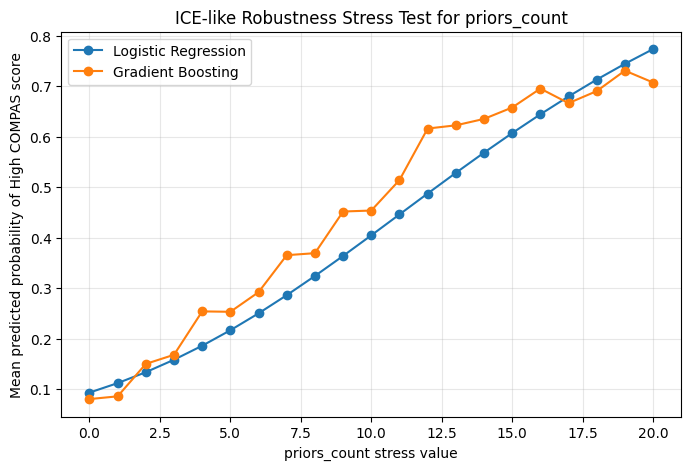

,model,feature,min_mean_score,max_mean_score,range_mean_score,sensitivity_index
0,Logistic Regression,priors_count,0.0933,0.7735,0.6802,0.0483
1,Gradient Boosting,priors_count,0.0804,0.7308,0.6504,0.0478



Answer:
Logistic Regression: mean predicted score ranges from 0.093 to 0.773, with range 0.680 and sensitivity index 0.04832.
Gradient Boosting: mean predicted score ranges from 0.080 to 0.731, with range 0.650 and sensitivity index 0.04776.
The curves should be interpreted as a robustness stress test: gradual movement suggests stable behavior, while abrupt jumps or a large range would indicate a deployment-risk failure mode.


In [13]:
def ice_mean_curve(model, X_ref, feature_col, values):
    means = []
    for v in values:
        X_temp = X_ref.copy()
        X_temp[feature_col] = v
        means.append(model.predict_proba(X_temp)[:, 1].mean())
    return np.array(means)

values = np.arange(0, 21)
sensitivity_rows = []
plt.figure(figsize=(8, 5))

for name, model in models.items():
    means = ice_mean_curve(model, X_test, "priors_count", values)
    plt.plot(values, means, marker="o", label=name)
    sensitivity_rows.append({
        "model": name,
        "feature": "priors_count",
        "min_mean_score": means.min(),
        "max_mean_score": means.max(),
        "range_mean_score": means.max() - means.min(),
        "sensitivity_index": np.var(means),
    })

plt.xlabel("priors_count stress value")
plt.ylabel("Mean predicted probability of High COMPAS score")
plt.title("ICE-like Robustness Stress Test for priors_count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table.round(4))

print("\nAnswer:")
for _, row in sensitivity_table.iterrows():
    print(
        f"{row['model']}: mean predicted score ranges from {row['min_mean_score']:.3f} to "
        f"{row['max_mean_score']:.3f}, with range {row['range_mean_score']:.3f} and sensitivity index "
        f"{row['sensitivity_index']:.5f}."
    )
print(
    "The curves should be interpreted as a robustness stress test: gradual movement suggests stable behavior, while abrupt jumps or a large range would indicate a deployment-risk failure mode."
)



Both models show smooth and monotonic increases in predicted risk as priors_count increases, indicating stable behavior.

The prediction range is approximately 0.68 for Logistic Regression and 0.65 for Gradient Boosting, suggesting strong sensitivity to this feature.

The models are robust in the sense that they respond consistently to changes in priors_count, but this also indicates heavy reliance on this feature, which may require domain justification.

## Part E: Slice-Based Evaluation

This section reports subgroup performance by race, sex, age group, and charge degree. It includes AUC, accuracy, Brier score, FPR, and FNR so the audit does not hide subgroup failures behind aggregate performance.

In [15]:
def safe_auc(y_true, prob):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)


def fpr_fnr(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return fpr, fnr


def slice_metrics(model, X_ref, y_ref, group_col, min_n=20):
    rows = []
    prob_all = model.predict_proba(X_ref)[:, 1]
    pred_all = (prob_all >= 0.5).astype(int)
    for value in sorted(X_ref[group_col].dropna().unique(), key=lambda x: str(x)):
        mask = X_ref[group_col] == value
        n = int(mask.sum())
        if n < min_n:
            continue
        y_slice = y_ref[mask]
        prob_slice = prob_all[mask]
        pred_slice = pred_all[mask]
        fpr, fnr = fpr_fnr(y_slice, pred_slice)
        rows.append({
            "slice_feature": group_col,
            "slice_value": value,
            "n": n,
            "base_rate": y_slice.mean(),
            "AUC": safe_auc(y_slice, prob_slice),
            "accuracy": accuracy_score(y_slice, pred_slice),
            "Brier": brier_score_loss(y_slice, prob_slice),
            "FPR": fpr,
            "FNR": fnr,
        })
    return pd.DataFrame(rows)

X_test_slices = X_test.copy()
X_test_slices["age_group"] = pd.cut(
    X_test_slices["age"],
    bins=[0, 25, 45, 100],
    labels=["<25", "25-45", "45+"],
    include_lowest=True,
)

slice_features = ["race", "sex", "age_group", "c_charge_degree"]
all_slice_results = []

for name, model in models.items():
    model_slice_tables = []
    for group_col in slice_features:
        temp = slice_metrics(model, X_test_slices, y_test, group_col=group_col, min_n=20)
        temp["model"] = name
        model_slice_tables.append(temp)
    model_slice_table = pd.concat(model_slice_tables, ignore_index=True)
    all_slice_results.append(model_slice_table)
    print(f"\n=== Slice-Based Evaluation: {name} ===")
    display(model_slice_table.sort_values(["slice_feature", "n"], ascending=[True, False]).round(4))

all_slice_results = pd.concat(all_slice_results, ignore_index=True)

print("\nAnswer:")
for name in models:
    temp = all_slice_results[all_slice_results["model"] == name]
    worst_auc = temp.loc[temp["AUC"].idxmin()] if temp["AUC"].notna().any() else None
    highest_fpr = temp.loc[temp["FPR"].idxmax()] if temp["FPR"].notna().any() else None
    highest_fnr = temp.loc[temp["FNR"].idxmax()] if temp["FNR"].notna().any() else None
    print(f"{name}:")
    if worst_auc is not None:
        print(f"  Lowest AUC slice: {worst_auc['slice_feature']}={worst_auc['slice_value']} with AUC={worst_auc['AUC']:.3f}.")
    if highest_fpr is not None:
        print(f"  Highest FPR slice: {highest_fpr['slice_feature']}={highest_fpr['slice_value']} with FPR={highest_fpr['FPR']:.3f}.")
    if highest_fnr is not None:
        print(f"  Highest FNR slice: {highest_fnr['slice_feature']}={highest_fnr['slice_value']} with FNR={highest_fnr['FNR']:.3f}.")
print(
    "Subgroups with lower AUC/accuracy, higher Brier score, or noticeably different FPR/FNR should be treated as governance priorities, especially when the slice size is meaningful."
)


=== Slice-Based Evaluation: Logistic Regression ===


,slice_feature,slice_value,n,base_rate,AUC,accuracy,Brier,FPR,FNR,model
6,age_group,25-45,661,0.1967,0.8393,0.8336,0.1110,0.0452,0.6615,Logistic Regression
8,age_group,<25,333,0.2402,0.7241,0.7688,0.1609,0.0158,0.9125,Logistic Regression
7,age_group,45+,241,0.0788,0.9122,0.9419,0.0479,0.0135,0.5789,Logistic Regression
9,c_charge_degree,F,795,0.2289,0.8244,0.8000,0.1328,0.0489,0.7088,Logistic Regression
10,c_charge_degree,M,440,0.1068,0.8139,0.9045,0.0748,0.0025,0.8723,Logistic Regression
0,race,African-American,655,0.2763,0.8094,0.7771,0.1495,0.0485,0.6796,Logistic Regression
1,race,Caucasian,409,0.0954,0.8231,0.8924,0.0767,0.0162,0.9744,Logistic Regression
2,race,Hispanic,106,0.0566,0.6933,0.9245,0.0653,0.0200,1.0000,Logistic Regression
3,race,Other,58,0.0517,0.9455,0.9483,0.0375,0.0000,1.0000,Logistic Regression
5,sex,Male,1022,0.2006,0.8318,0.8209,0.1201,0.0379,0.7415,Logistic Regression



=== Slice-Based Evaluation: Gradient Boosting ===


,slice_feature,slice_value,n,base_rate,AUC,accuracy,Brier,FPR,FNR,model
6,age_group,25-45,661,0.1967,0.8316,0.8275,0.1143,0.0527,0.6615,Gradient Boosting
8,age_group,<25,333,0.2402,0.7344,0.7688,0.1618,0.0474,0.8125,Gradient Boosting
7,age_group,45+,241,0.0788,0.9237,0.9295,0.0515,0.0225,0.6316,Gradient Boosting
9,c_charge_degree,F,795,0.2289,0.8137,0.7925,0.1375,0.0669,0.6813,Gradient Boosting
10,c_charge_degree,M,440,0.1068,0.8284,0.9023,0.0739,0.0102,0.8298,Gradient Boosting
0,race,African-American,655,0.2763,0.8052,0.7725,0.1519,0.0654,0.6519,Gradient Boosting
1,race,Caucasian,409,0.0954,0.8165,0.8826,0.0797,0.0297,0.9487,Gradient Boosting
2,race,Hispanic,106,0.0566,0.6517,0.9151,0.0707,0.0300,1.0000,Gradient Boosting
3,race,Other,58,0.0517,0.9333,0.9655,0.0383,0.0000,0.6667,Gradient Boosting
5,sex,Male,1022,0.2006,0.8290,0.8160,0.1227,0.0514,0.7122,Gradient Boosting



Answer:
Logistic Regression:
  Lowest AUC slice: race=Hispanic with AUC=0.693.
  Highest FPR slice: c_charge_degree=F with FPR=0.049.
  Highest FNR slice: race=Hispanic with FNR=1.000.
Gradient Boosting:
  Lowest AUC slice: race=Hispanic with AUC=0.652.
  Highest FPR slice: c_charge_degree=F with FPR=0.067.
  Highest FNR slice: race=Hispanic with FNR=1.000.
Subgroups with lower AUC/accuracy, higher Brier score, or noticeably different FPR/FNR should be treated as governance priorities, especially when the slice size is meaningful.




Subgroup analysis reveals substantial disparities across race groups. Hispanic defendants experience the lowest AUC (as low as 0.652), indicating poor predictive performance.

More critically, the false negative rate (FNR) for this group reaches 1.000, meaning the model fails to correctly identify any positive cases in that subgroup.

FPR also varies across groups, indicating uneven error distribution.

hese disparities represent a serious fairness failure and would be unacceptable in high-stakes deployment without mitigation.

## Final Audit Summary

This final block collects the main findings using the actual outputs above.

In [19]:
summary_rows = []

summary_rows.append({
    "section": "Distribution drift",
    "key_metric": "max numeric PSI",
    "value": max_psi,
    "interpretation": "Low" if max_psi < 0.10 else "Potential drift",
})
summary_rows.append({
    "section": "Distribution drift",
    "key_metric": "encoded MMD^2",
    "value": mmd_value,
    "interpretation": "Use with PSI/KS; lower indicates more similar train/test distributions",
})
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "Generalization",
        "key_metric": f"{row['model']} AUC gap",
        "value": row["generalization_gap_auc"],
        "interpretation": "Small" if abs(row["generalization_gap_auc"]) <= 0.05 else "Large",
    })
summary_rows.append({
    "section": "Spurious correlation",
    "key_metric": "largest counterfactual shift",
    "value": swap_table["mean_abs_shift"].max(),
    "interpretation": "Protected-attribute/proxy reliance should be reviewed",
})
summary_rows.append({
    "section": "Robustness",
    "key_metric": "largest priors_count response range",
    "value": sensitivity_table["range_mean_score"].max(),
    "interpretation": "Review for domain justification",
})
summary_rows.append({
    "section": "Slice evaluation",
    "key_metric": "largest subgroup FPR",
    "value": all_slice_results["FPR"].max(),
    "interpretation": "Fairness monitoring required",
})

summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(4))





,section,key_metric,value,interpretation
0,Distribution drift,max numeric PSI,0.0076,Low
1,Distribution drift,encoded MMD^2,0.0019,Use with PSI/KS; lower indicates more similar ...
2,Generalization,Logistic Regression AUC gap,-0.0054,Small
3,Generalization,Gradient Boosting AUC gap,0.0247,Small
4,Spurious correlation,largest counterfactual shift,0.0553,Protected-attribute/proxy reliance should be r...
5,Robustness,largest priors_count response range,0.6802,Review for domain justification
6,Slice evaluation,largest subgroup FPR,0.0669,Fairness monitoring required




The audit finds no evidence of distribution drift and only minor generalization gaps, indicating stable model performance overall.

However, the most critical issue is the presence of spurious correlations and subgroup disparities. Counterfactual analysis shows that predictions shift significantly when protected attributes are changed, and slice-based evaluation reveals severe performance failures for certain groups, including an FNR of 1.000 for Hispanic defendants.

These findings indicate that the model relies on protected attributes or their proxies and produces unequal error rates across groups.

Deployment should only proceed with strong governance controls, including fairness monitoring, bias mitigation, and regular auditing of subgroup performance.